# Clean Transformer for UNSW-NB15

This notebook trains a Transformer model without data loading bugs or attack bias.

In [7]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path("../../").resolve()))

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from src.models.classical.transformer import TransformerClassifier

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

In [8]:
CONFIG = {
    "batch_size": 256,
    "epochs": 50,
    "learning_rate": 0.0005,
    "weight_decay": 1e-4,
    "embed_dim": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_blocks": 3,
    "dense_units": [64],
    "dropout": 0.3,
    "patience": 10,
}

CATEGORICAL_COLS = ['proto', 'service', 'state']
DROP_COLS = ['id', 'attack_cat']
LABEL_COL = 'label'

DATA_DIR = Path("../../data/raw/unsw-nb15")

def load_unsw_nb15(filepath, scaler=None, label_encoders=None, fit=True):
    df = pd.read_csv(filepath)
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    
    y = df[LABEL_COL].values
    X = df.drop(columns=[LABEL_COL])

    X_cat = pd.DataFrame(index=X.index)
    if fit:
        label_encoders = {}
        for col in CATEGORICAL_COLS:
            le = LabelEncoder()
            X[col] = X[col].fillna('unknown').astype(str)
            known_classes = np.append(X[col].unique(), 'unknown')
            le.fit(known_classes)
            X_cat[col] = le.transform(X[col])
            label_encoders[col] = le
    else:
        for col in CATEGORICAL_COLS:
            X[col] = X[col].fillna('unknown').astype(str)
            X[col] = X[col].apply(lambda x: x if x in label_encoders[col].classes_ else 'unknown')
            X_cat[col] = label_encoders[col].transform(X[col])

    X_num = X.drop(columns=CATEGORICAL_COLS).fillna(0)
    X_num_vals = X_num.values.astype(np.float32)
    
    if fit:
        scaler = StandardScaler()
        X_num_vals = scaler.fit_transform(X_num_vals)
    else:
        X_num_vals = scaler.transform(X_num_vals)
        
    return X_num_vals, X_cat.values.astype(np.float32), y, scaler, label_encoders

In [9]:
try:
    X_train_num, X_train_cat, y_train, scaler, label_encoders = load_unsw_nb15(
        DATA_DIR / "UNSW_NB15_training-set.csv", fit=True
    )
    
    X_test_num, X_test_cat, y_test, _, _ = load_unsw_nb15(
        DATA_DIR / "UNSW_NB15_testing-set.csv",
        scaler=scaler, label_encoders=label_encoders, fit=False
    )
    
    # Combine back to single arrays for our model
    X_train_full = np.hstack([X_train_num, X_train_cat])
    X_test = np.hstack([X_test_num, X_test_cat])
    
    val_size = int(0.1 * len(X_train_full))
    indices = np.random.permutation(len(X_train_full))
    
    X_val = X_train_full[indices[:val_size]]
    y_val = y_train[indices[:val_size]]
    
    X_train = X_train_full[indices[val_size:]]
    y_train = y_train[indices[val_size:]]
    
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    
except FileNotFoundError:
    print("❌ Dataset not found! Please download UNSW-NB15 CSV files.")

Train: (74099, 42), Val: (8233, 42), Test: (175341, 42)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if 'X_train' in globals():
    model = TransformerClassifier(
        input_dim=X_train.shape[1],
        num_classes=2,
        embed_dim=CONFIG["embed_dim"],
        num_heads=CONFIG["num_heads"],
        ff_dim=CONFIG["ff_dim"],
        num_blocks=CONFIG["num_blocks"],
        dense_units=CONFIG["dense_units"],
        dropout=CONFIG["dropout"]
    ).to(device)
    
    print(f"Model allocated on {device}")

    class_counts = np.bincount(y_train)
    class_weights = torch.FloatTensor([1.0, 4.0]).to(device)

    class FocalLoss(nn.Module):
        def __init__(self, weight=None, gamma=2, reduction='mean'):
            super(FocalLoss, self).__init__()
            self.weight = weight
            self.gamma = gamma
            self.reduction = reduction

        def forward(self, inputs, targets):
            ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
            pt = torch.exp(-ce_loss)
            focal_loss = ((1 - pt)**self.gamma) * ce_loss
            if self.reduction == 'mean':
                return focal_loss.mean()
            return focal_loss.sum()
    
    criterion = FocalLoss(weight=class_weights, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    
    train_set = torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_set = torch.utils.data.TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    test_set = torch.utils.data.TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size=CONFIG["batch_size"], shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=CONFIG["batch_size"], shuffle=False)


Model allocated on cuda


c:\Users\musab\Projects\NIDS-DL\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, pred = outputs.max(1)
        total += y_batch.size(0)
        correct += pred.eq(y_batch).sum().item()
        
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            _, pred = outputs.max(1)
            total += y_batch.size(0)
            correct += pred.eq(y_batch).sum().item()
    return total_loss / len(loader), correct / total

if 'X_train' in globals():
    best_val_acc = 0
    
    for epoch in range(CONFIG["epochs"]):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "../../results/models/transformer_unsw.pt")
            
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 5 | Train Acc: 0.8253 | Train Loss: 0.2432 | Val Acc: 0.8598
Epoch 10 | Train Acc: 0.8717 | Train Loss: 0.1779 | Val Acc: 0.9343
Epoch 15 | Train Acc: 0.8898 | Train Loss: 0.1580 | Val Acc: 0.9325
Epoch 20 | Train Acc: 0.8996 | Train Loss: 0.1419 | Val Acc: 0.9344
Epoch 25 | Train Acc: 0.9050 | Train Loss: 0.1360 | Val Acc: 0.9456
Epoch 30 | Train Acc: 0.9073 | Train Loss: 0.1322 | Val Acc: 0.9440
Epoch 35 | Train Acc: 0.9067 | Train Loss: 0.1317 | Val Acc: 0.9428
Epoch 40 | Train Acc: 0.9083 | Train Loss: 0.1299 | Val Acc: 0.9402
Epoch 45 | Train Acc: 0.9072 | Train Loss: 0.1307 | Val Acc: 0.9432
Epoch 50 | Train Acc: 0.9081 | Train Loss: 0.1297 | Val Acc: 0.9400


C:\Users\musab\AppData\Local\Temp\ipykernel_65632\3121963.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../../results/models/transfor

Test Accuracy: 0.9090
              precision    recall  f1-score   support

      Normal       0.80      0.96      0.87     56000
      Attack       0.98      0.88      0.93    119341

    accuracy                           0.91    175341
   macro avg       0.89      0.92      0.90    175341
weighted avg       0.92      0.91      0.91    175341



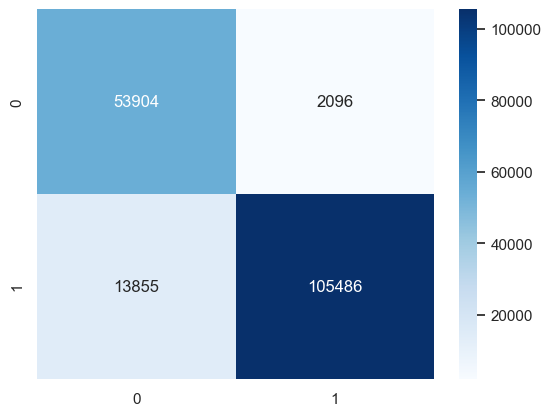

4300

In [12]:
if 'X_test' in globals():
    model.load_state_dict(torch.load("../../results/models/transformer_unsw.pt"))
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, pred = outputs.max(1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            
    print(classification_report(all_labels, all_preds, target_names=['Normal', 'Attack']))
    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
    plt.show()

torch.cuda.empty_cache()
import gc
gc.collect()